<a href="https://colab.research.google.com/github/RifaldiAchmad/Maxim-App-Sentiment-Analysis/blob/main/wordcloud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import re
import requests
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from wordcloud import WordCloud, STOPWORDS

import nltk
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
data = pd.read_csv('/content/aspek.csv')
data

,index,teks,aspek,sentimen,waktu
0,0,pencariannya lama banget padahal banyak yg online,Kinerja Aplikasi (Error/Bug/Lambat),Negatif,2025-02-28 23:45:49
1,1,pencariannya lama banget padahal banyak yg online,Ketersediaan Driver (Lama Menunggu),Negatif,2025-02-28 23:45:49
2,2,slalu pakai maxim,Umum,Positif,2025-02-28 23:00:33
3,3,bagus pelayanan nya orangnya ramah,Perilaku & Profesionalisme Driver,Positif,2025-02-28 22:55:05
4,4,"nyari alamat susah banget, udah ku tulis sejel...",Akurasi GPS & Peta,Negatif,2025-02-28 22:52:00
...,...,...,...,...,...
49889,49889,"sip,driver ramah ,respon cepat",Perilaku & Profesionalisme Driver,Positif,2024-03-01 01:13:42
49890,49890,"sip,driver ramah ,respon cepat",Ketersediaan Driver (Lama Menunggu),Positif,2024-03-01 01:13:42
49891,49891,"Apa si Maxim ni, blm jga dipakek baru mau daft...",Kinerja Aplikasi (Error/Bug/Lambat),Negatif,2024-03-01 00:54:39
49892,49892,"Apa si Maxim ni, blm jga dipakek baru mau daft...",Customer Service,Negatif,2024-03-01 00:54:39


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49894 entries, 0 to 49893
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   index     49894 non-null  int64 
 1   teks      49894 non-null  object
 2   aspek     49894 non-null  object
 3   sentimen  49894 non-null  object
 4   waktu     49894 non-null  object
dtypes: int64(1), object(4)
memory usage: 1.9+ MB


In [ ]:
data.aspek.value_counts()

,count
aspek,
Perilaku & Profesionalisme Driver,15783
Umum,11351
Ketersediaan Driver (Lama Menunggu),6273
Harga & Tarif,3393
Kinerja Aplikasi (Error/Bug/Lambat),2483
Akurasi GPS & Peta,2385
UI/UX Aplikasi (Tampilan/Desain),1722
Customer Service,1706
Kualitas Layanan Pesan Antar (Food/Delivery),1601


In [ ]:
def add_word_columns_to_df(df, text_column_name):
  new_df = df.copy()
  for index, row in new_df.iterrows():
    text = row[text_column_name]
    words = text.split()
    for i, word in enumerate(words):
      new_col_name = f'{text_column_name}_word_{i+1}'
      new_df.at[index, new_col_name] = word
  return new_df

In [ ]:
dataset = add_word_columns_to_df(data, 'teks')

In [ ]:
dataset.head()

,index,teks,aspek,sentimen,waktu,teks_word_1,teks_word_2,teks_word_3,teks_word_4,teks_word_5,...,teks_word_102,teks_word_103,teks_word_104,teks_word_105,teks_word_106,teks_word_107,teks_word_108,teks_word_109,teks_word_110,teks_word_111
0,0,pencariannya lama banget padahal banyak yg online,Kinerja Aplikasi (Error/Bug/Lambat),Negatif,2025-02-28 23:45:49,pencariannya,lama,banget,padahal,banyak,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,pencariannya lama banget padahal banyak yg online,Ketersediaan Driver (Lama Menunggu),Negatif,2025-02-28 23:45:49,pencariannya,lama,banget,padahal,banyak,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,slalu pakai maxim,Umum,Positif,2025-02-28 23:00:33,slalu,pakai,maxim,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,bagus pelayanan nya orangnya ramah,Perilaku & Profesionalisme Driver,Positif,2025-02-28 22:55:05,bagus,pelayanan,nya,orangnya,ramah,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,"nyari alamat susah banget, udah ku tulis sejel...",Akurasi GPS & Peta,Negatif,2025-02-28 22:52:00,nyari,alamat,susah,"banget,",udah,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
words_long_format = []
for index, row in dataset.iterrows():
    for col in dataset.columns:
        if col.startswith('teks_word_'):
            word = row[col]
            if pd.notna(word):
                words_long_format.append({'index': index, 'word': word})

words_df = pd.DataFrame(words_long_format)
words_df

,index,word
0,0,pencariannya
1,0,lama
2,0,banget
3,0,padahal
4,0,banyak
...,...,...
622013,49893,untuk
622014,49893,car
622015,49893,delivery
622016,49893,dimaksimalin


In [ ]:
words_df['word'] = words_df['word'].str.lower()
words_df

,index,word
0,0,pencariannya
1,0,lama
2,0,banget
3,0,padahal
4,0,banyak
...,...,...
622013,49893,untuk
622014,49893,car
622015,49893,delivery
622016,49893,dimaksimalin


In [ ]:
words_df['word'] = words_df['word'].apply(lambda x: re.sub(r'[^a-zA-Z]', '', str(x)))
words_df

,index,word
0,0,pencariannya
1,0,lama
2,0,banget
3,0,padahal
4,0,banyak
...,...,...
622013,49893,untuk
622014,49893,car
622015,49893,delivery
622016,49893,dimaksimalin


In [ ]:
def remove_repeated_chars(word):
  """
  hapus karakter yg sama berulangkali berurutan lebih dari 2 karakter pada word di words
  """
  return re.sub(r'(.)\1{2,}', r'\1\1', word)

words_df['word'] = words_df['word'].apply(remove_repeated_chars)
words_df

,index,word
0,0,pencariannya
1,0,lama
2,0,banget
3,0,padahal
4,0,banyak
...,...,...
622013,49893,untuk
622014,49893,car
622015,49893,delivery
622016,49893,dimaksimalin


In [ ]:
def remove_leading_trailing_repeated_chars(word):
  """
  hapus karakter yang sama berulang jika lebih dari 1 karakter di akhir dan awal kata
  """
  # Remove leading repeated characters
  word = re.sub(r'^([a-zA-Z])\1+', r'\1', word)
  # Remove trailing repeated characters
  word = re.sub(r'([a-zA-Z])\1+$', r'\1', word)
  return word

words_df['word'] = words_df['word'].apply(remove_leading_trailing_repeated_chars)
words_df

,index,word
0,0,pencariannya
1,0,lama
2,0,banget
3,0,padahal
4,0,banyak
...,...,...
622013,49893,untuk
622014,49893,car
622015,49893,delivery
622016,49893,dimaksimalin


In [ ]:
url = "https://raw.githubusercontent.com/RifaldiAchmad/Internship-Taudata/refs/heads/main/stopwords_id.txt"
response = requests.get(url)
stopwords_id = response.text.splitlines()
print(stopwords_id)

['ada', 'adalah', 'adanya', 'adapun', 'agak', 'agaknya', 'agar', 'akan', 'akankah', 'akhir', 'akhiri', 'akhirnya', 'aku', 'akulah', 'amat', 'amatlah', 'anda', 'andalah', 'antar', 'antara', 'antaranya', 'apa', 'apaan', 'apabila', 'apakah', 'apalagi', 'apatah', 'artinya', 'asal', 'asalkan', 'atas', 'atau', 'ataukah', 'ataupun', 'awal', 'awalnya', 'bagai', 'bagaikan', 'bagaimana', 'bagaimanakah', 'bagaimanapun', 'bagi', 'bagian', 'bahkan', 'bahwa', 'bahwasanya', 'baik', 'bakal', 'bakalan', 'balik', 'banyak', 'bapak', 'baru', 'bawah', 'beberapa', 'begini', 'beginian', 'beginikah', 'beginilah', 'begitu', 'begitukah', 'begitulah', 'begitupun', 'bekerja', 'belakang', 'belakangan', 'belum', 'belumlah', 'benar', 'benarkah', 'benarlah', 'berada', 'berakhir', 'berakhirlah', 'berakhirnya', 'berapa', 'berapakah', 'berapalah', 'berapapun', 'berarti', 'berawal', 'berbagai', 'berdatangan', 'beri', 'berikan', 'berikut', 'berikutnya', 'berjumlah', 'berkali-kali', 'berkata', 'berkehendak', 'berkeinginan'

In [ ]:
# Create a set of stopwords for efficient lookup
stopwords_set = set(stopwords_id)

# Filter words_df to remove words present in the stopwords set
words_df = words_df[~words_df['word'].isin(stopwords_set)]
words_df

,index,word
0,0,pencariannya
2,0,banget
5,0,yg
6,0,online
7,1,pencariannya
...,...,...
622012,49892,makeknya
622014,49893,car
622015,49893,delivery
622016,49893,dimaksimalin


In [ ]:
def remove_substring_from_end(word, substring):
  """
  hapus substring/suffix -nya di akhir kata
  """
  if word.endswith(substring):
    return word[:-len(substring)]
  return word

words_df['word'] = words_df['word'].apply(lambda x: remove_substring_from_end(x, 'nya'))
words_df

,index,word
0,0,pencarian
2,0,banget
5,0,yg
6,0,online
7,1,pencarian
...,...,...
622012,49892,makek
622014,49893,car
622015,49893,delivery
622016,49893,dimaksimalin


In [ ]:
words_df = words_df[words_df['word'].str.len() > 3]
words_df

,index,word
0,0,pencarian
2,0,banget
6,0,online
7,1,pencarian
9,1,banget
...,...,...
622009,49892,kode
622010,49892,gimana
622012,49892,makek
622015,49893,delivery


In [ ]:
words_df = words_df[words_df['word'].str.len() < 13]
words_df

,index,word
0,0,pencarian
2,0,banget
6,0,online
7,1,pencarian
9,1,banget
...,...,...
622009,49892,kode
622010,49892,gimana
622012,49892,makek
622015,49893,delivery


In [ ]:
words_df.word.nunique()

15297

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


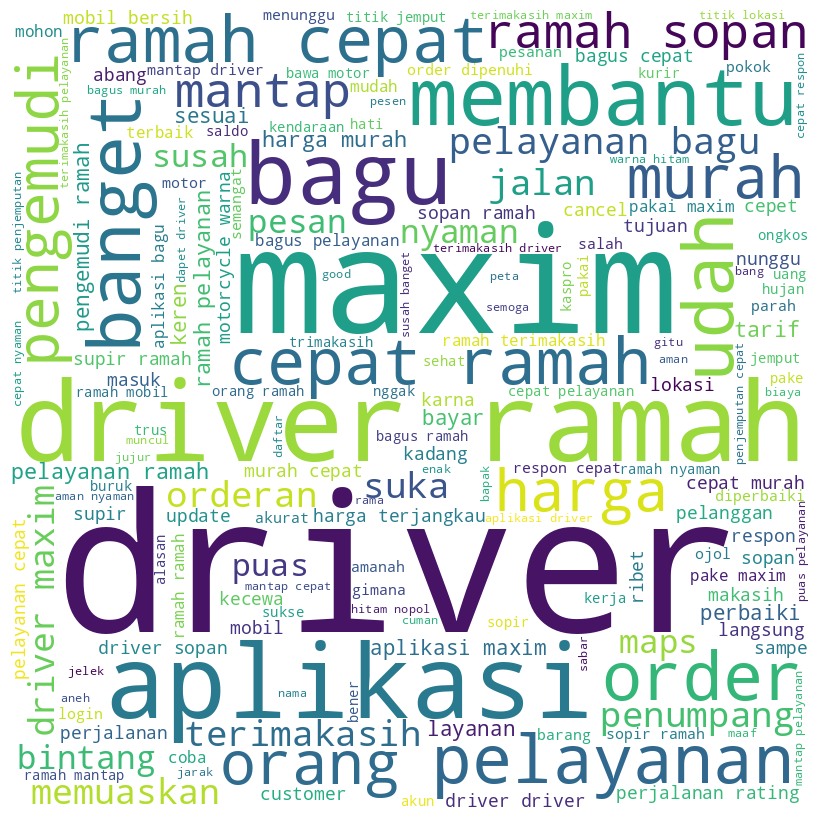

In [ ]:
# Gabungkan isi kolom 'word' menjadi satu string
all_words = ' '.join(words_df['word'].dropna()).lower()

# Tokenisasi menggunakan nltk
tokens = word_tokenize(all_words)

# Filter hanya kata yang berupa huruf (tanpa angka/simbol)
tokens = [word for word in tokens if word.isalpha()]

# Gabungkan kembali token menjadi string untuk WordCloud
clean_text = ' '.join(tokens)

# Tambahkan stopwords khusus
custom_stopwords = STOPWORDS.union({'tidak', 'kalo', 'terima', 'kasih', 'sangat', 'tolong', 'tapi', 'biar', 'kali'})

# Buat WordCloud
wordcloud = WordCloud(
    width=800,
    height=800,
    background_color='white',
    stopwords=custom_stopwords,
    min_font_size=10
).generate(clean_text)

# Tampilkan WordCloud
plt.figure(figsize=(8, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.tight_layout(pad=0)
plt.show()

In [ ]:
words_df.to_csv('kata.csv', index=False)